# ĐÁP ÁN — Bài kiểm tra Lập trình phân tích dữ liệu (60 phút)
Notebook tham chiếu cho giảng viên. Các con số in ra ở mỗi ô là **kết quả chuẩn** để đối chiếu bài làm.

In [1]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_DIR = Path('../du_lieu')

## Phần A — Python thuần: xử lý tập tin văn bản (2,0 điểm)
### A1 (1,0 đ) Lọc dòng hợp lệ bằng regex, ghi dòng lỗi ra file

In [2]:
MAU = re.compile(r'\d{4}-\d{2}-\d{2} \d{2}:\d{2} \| DH\d{5} \| '
                 r'(GIAO_THANH_CONG|THAT_BAI|HOAN_TRA) \| shipper=(SP\d{2})')

hop_le, loi = [], []
with open(DATA_DIR / 'nhat_ky_giao_hang.txt', encoding='utf-8') as f:
    for dong in f:
        dong = dong.rstrip('\n')
        if dong.strip() == '' or dong.startswith('#'):
            continue
        (hop_le if MAU.fullmatch(dong) else loi).append(dong)

with open('dong_loi.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(loi) + '\n')

print('Số dòng hợp lệ    :', len(hop_le))
print('Số dòng không hợp lệ:', len(loi))
print(Counter(MAU.fullmatch(d).group(1) for d in hop_le))

Số dòng hợp lệ    : 880
Số dòng không hợp lệ: 42
Counter({'GIAO_THANH_CONG': 763, 'THAT_BAI': 81, 'HOAN_TRA': 36})


### A2 (1,0 đ) Hàm tính tỉ lệ giao thành công theo shipper

In [3]:
def ti_le_thanh_cong(cac_dong, toi_thieu=20):
    tong, thanh_cong = Counter(), Counter()
    for d in cac_dong:
        trang_thai, sp = MAU.fullmatch(d).groups()
        tong[sp] += 1
        if trang_thai == 'GIAO_THANH_CONG':
            thanh_cong[sp] += 1
    return {sp: thanh_cong[sp] / n for sp, n in tong.items() if n >= toi_thieu}


kq = ti_le_thanh_cong(hop_le)
for sp in sorted(kq):
    print(f'{sp}: {kq[sp]:.3f}')
sp_thap = min(kq, key=kq.get)
print(f'\nShipper tỉ lệ thấp nhất (>= 20 đơn): {sp_thap} — {kq[sp_thap]:.1%}')

# Kiểm tra bẫy: shipper bị loại vì không đủ 20 đơn
tat_ca = ti_le_thanh_cong(hop_le, toi_thieu=0)
print('Bị loại vì < 20 đơn:', {sp: f'{v:.1%}' for sp, v in tat_ca.items() if sp not in kq})

SP01: 0.904
SP02: 0.910
SP03: 0.774
SP04: 0.886
SP05: 0.946
SP06: 0.910
SP07: 0.670
SP08: 0.911
SP09: 0.904
SP10: 0.888

Shipper tỉ lệ thấp nhất (>= 20 đơn): SP07 — 67.0%
Bị loại vì < 20 đơn: {'SP11': '33.3%'}


## Phần B — Pandas: đọc, làm sạch, ghép bảng (3,0 điểm)
### B1 (0,5 đ) Đọc dữ liệu & khảo sát

In [4]:
dh = pd.read_csv(DATA_DIR / 'don_hang.csv')
kh = pd.read_excel(DATA_DIR / 'khach_hang.xlsx', sheet_name='khach_hang')
hang = pd.read_excel(DATA_DIR / 'khach_hang.xlsx', sheet_name='hang_thanh_vien')

dh['ngay_dat'] = pd.to_datetime(dh['ngay_dat'], format='%d/%m/%Y')

print('don_hang  :', dh.shape)
print('khach_hang:', kh.shape)
print('\nSố giá trị thiếu theo cột:')
print(dh.isna().sum()[lambda s: s > 0])

don_hang  : (2436, 9)
khach_hang: (500, 5)

Số giá trị thiếu theo cột:
ma_kh       156
so_luong     72
danh_gia    488
dtype: int64


### B2 (1,5 đ) Làm sạch theo đúng 4 bước

In [5]:
n0 = len(dh)

# Bước 1 — bỏ dòng trùng hoàn toàn
dh = dh.drop_duplicates()
n1 = len(dh)

# Bước 2 — chuẩn hoá tên thành phố
dh['thanh_pho'] = dh['thanh_pho'].str.strip().str.title()
dem_tp = dh['thanh_pho'].value_counts()

# Bước 3 — bỏ so_luong > 100, GIỮ dòng đang trống
# (bẫy: dh[dh.so_luong <= 100] sẽ xoá luôn các dòng NaN)
dh = dh[~(dh['so_luong'] > 100)]
n3 = len(dh)

# Bước 4 — điền so_luong trống bằng trung vị theo danh_muc
trung_vi = dh.groupby('danh_muc')['so_luong'].transform('median')
dh['so_luong'] = dh['so_luong'].fillna(trung_vi).astype(int)

print('Ban đầu              :', n0)
print('Sau bước 1 (trùng)   :', n1, f'(bỏ {n0 - n1})')
print('Sau bước 3 (ngoại lai):', n3, f'(bỏ {n1 - n3})')
print('\nTrung vị so_luong theo danh mục:')
print(dh.groupby('danh_muc')['so_luong'].median())
print('\nSố đơn theo thành phố (sau bước 2):')
print(dem_tp)
print('\nCòn giá trị thiếu ở so_luong:', dh['so_luong'].isna().sum())

Ban đầu              : 2436
Sau bước 1 (trùng)   : 2400 (bỏ 36)
Sau bước 3 (ngoại lai): 2391 (bỏ 9)

Trung vị so_luong theo danh mục:
danh_muc
Gia dụng          2.0
Mỹ phẩm           3.0
Thực phẩm         3.0
Văn phòng phẩm    4.0
Đồ uống           4.0
Name: so_luong, dtype: float64

Số đơn theo thành phố (sau bước 2):
thanh_pho
Hồ Chí Minh    772
Hà Nội         746
Đà Nẵng        352
Cần Thơ        285
Huế            245
Name: count, dtype: int64

Còn giá trị thiếu ở so_luong: 0


### B3 (1,0 đ) Ghép bảng & tính thành tiền

In [6]:
kh_day_du = kh.merge(hang, on='hang_thanh_vien', how='left')
df = dh.merge(kh_day_du[['ma_kh', 'gioi_tinh', 'nam_sinh', 'hang_thanh_vien', 'chiet_khau']],
              on='ma_kh', how='left')
assert len(df) == len(dh)

so_khong_khop = df['hang_thanh_vien'].isna().sum()
df['hang_thanh_vien'] = df['hang_thanh_vien'].fillna('Vãng lai')
df['chiet_khau'] = df['chiet_khau'].fillna(0)
df['thanh_tien'] = df['so_luong'] * df['don_gia'] * (1 - df['chiet_khau'])

print('Số dòng sau ghép         :', len(df))
print('Số đơn vãng lai          :', so_khong_khop)
print(f'Tổng doanh thu (VNĐ)     : {df["thanh_tien"].sum():,.0f}')
print('\nSố đơn theo hạng:')
print(df['hang_thanh_vien'].value_counts())

Số dòng sau ghép         : 2391
Số đơn vãng lai          : 185
Tổng doanh thu (VNĐ)     : 814,222,950

Số đơn theo hạng:
hang_thanh_vien
Thường      1104
Bạc          710
Vàng         392
Vãng lai     185
Name: count, dtype: int64


## Phần C — Phân tích tổng hợp (2,0 điểm)
### C1 (1,0 đ) Doanh thu theo thành phố × danh mục (triệu đồng)

In [7]:
bang = pd.pivot_table(df, index='thanh_pho', columns='danh_muc', values='thanh_tien',
                      aggfunc='sum', margins=True, margins_name='Tổng') / 1e6
print(bang.round(1))

theo_tp = bang.drop(index='Tổng')['Tổng']
print('\nThành phố doanh thu cao nhất:', theo_tp.idxmax(), f'— {theo_tp.max():,.1f} triệu')
print('\nDanh mục dẫn đầu ở mỗi thành phố:')
print(bang.drop(index='Tổng').drop(columns='Tổng').idxmax(axis=1))

danh_muc     Gia dụng  Mỹ phẩm  Thực phẩm  Văn phòng phẩm  Đồ uống   Tổng
thanh_pho                                                                
Cần Thơ          16.6     17.1       35.6             3.1      9.9   82.2
Huế              10.9     15.2       24.8             3.0      9.2   63.0
Hà Nội           51.1    130.7       42.3            14.2     27.9  266.3
Hồ Chí Minh      65.7    131.5       49.3            15.5     24.5  286.5
Đà Nẵng          36.1     33.9       27.7             7.5     11.1  116.2
Tổng            180.3    328.4      179.7            43.3     82.6  814.2

Thành phố doanh thu cao nhất: Hồ Chí Minh — 286.5 triệu

Danh mục dẫn đầu ở mỗi thành phố:
thanh_pho
Cần Thơ        Thực phẩm
Huế            Thực phẩm
Hà Nội           Mỹ phẩm
Hồ Chí Minh      Mỹ phẩm
Đà Nẵng         Gia dụng
dtype: str


### C2 (1,0 đ) Doanh thu theo tháng & tăng trưởng

In [8]:
theo_thang = df.groupby(df['ngay_dat'].dt.month)['thanh_tien'].sum() / 1e6
tang_truong = theo_thang.pct_change() * 100
bang_thang = pd.DataFrame({'doanh_thu_trieu': theo_thang.round(1),
                           'tang_truong_%': tang_truong.round(1)})
print(bang_thang)
print('\nTháng tăng trưởng mạnh nhất so với tháng trước:',
      tang_truong.idxmax(), f'(+{tang_truong.max():.1f}%)')

          doanh_thu_trieu  tang_truong_%
ngay_dat                                
1                   135.7            NaN
2                    91.2          -32.8
3                   140.0           53.6
4                   129.4           -7.6
5                   128.6           -0.6
6                   189.3           47.1

Tháng tăng trưởng mạnh nhất so với tháng trước: 3 (+53.6%)


## Phần D — Trực quan hoá (1,5 điểm)

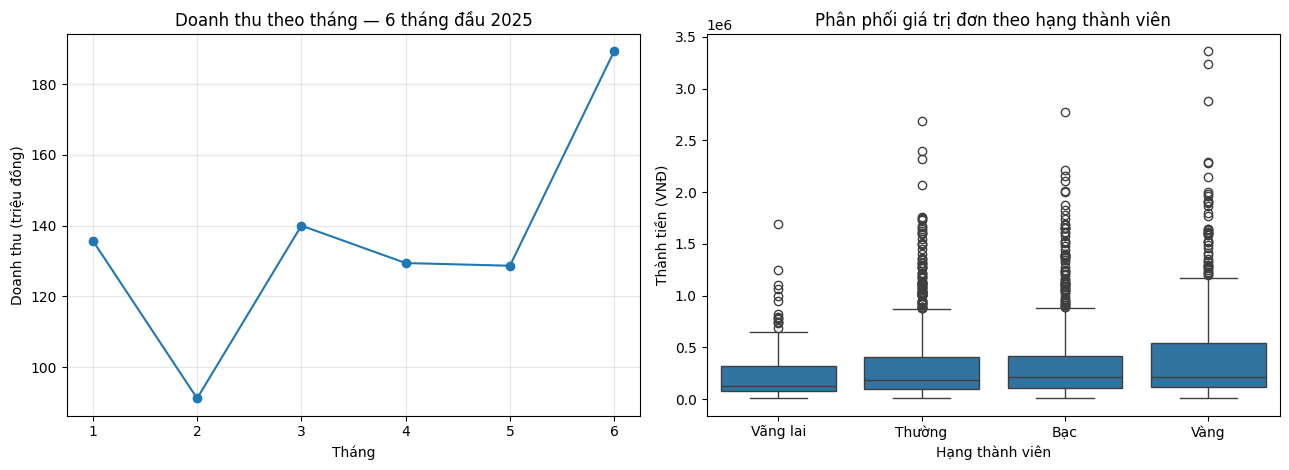

hang_thanh_vien
Bạc         209000.0
Thường      183500.0
Vàng        211050.0
Vãng lai    129000.0
Name: thanh_tien, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(theo_thang.index, theo_thang.values, marker='o')
axes[0].set_title('Doanh thu theo tháng — 6 tháng đầu 2025')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Doanh thu (triệu đồng)')
axes[0].set_xticks(range(1, 7))
axes[0].grid(alpha=0.3)

sns.boxplot(data=df, x='hang_thanh_vien', y='thanh_tien',
            order=['Vãng lai', 'Thường', 'Bạc', 'Vàng'], ax=axes[1])
axes[1].set_title('Phân phối giá trị đơn theo hạng thành viên')
axes[1].set_xlabel('Hạng thành viên')
axes[1].set_ylabel('Thành tiền (VNĐ)')

fig.tight_layout()
fig.savefig('bieu_do.png', dpi=150)
plt.show()

print(df.groupby('hang_thanh_vien')['thanh_tien'].median().round(0))

## Phần E — Thống kê suy luận (1,5 điểm)
### E1 (1,0 đ) Khách Vàng có giá trị đơn trung bình cao hơn khách Thường?
- H0: μ_Vàng ≤ μ_Thường
- H1: μ_Vàng > μ_Thường  (kiểm định một phía, Welch — không giả định phương sai bằng nhau)

In [10]:
vang = df.loc[df['hang_thanh_vien'] == 'Vàng', 'thanh_tien']
thuong = df.loc[df['hang_thanh_vien'] == 'Thường', 'thanh_tien']
t, p = stats.ttest_ind(vang, thuong, equal_var=False, alternative='greater')

print(f'n Vàng = {len(vang)},   trung bình = {vang.mean():,.0f}')
print(f'n Thường = {len(thuong)}, trung bình = {thuong.mean():,.0f}')
print(f't = {t:.3f}, p-value = {p:.2e}')
print('Kết luận:', 'Bác bỏ H0' if p < 0.05 else 'Chưa đủ cơ sở bác bỏ H0', '(α = 0,05)')

n Vàng = 392,   trung bình = 442,288
n Thường = 1104, trung bình = 314,714
t = 4.400, p-value = 6.58e-06
Kết luận: Bác bỏ H0 (α = 0,05)


### E2 (0,5 đ) Phương thức thanh toán có độc lập với thành phố?
- H0: phương thức thanh toán độc lập với thành phố
- H1: có liên hệ

In [11]:
bang_cheo = pd.crosstab(df['thanh_pho'], df['phuong_thuc_tt'])
chi2, p2, dof, _ = stats.chi2_contingency(bang_cheo)
print(bang_cheo)
print(f'\nχ² = {chi2:.2f}, bậc tự do = {dof}, p-value = {p2:.2e}')
print('Kết luận:', 'Bác bỏ H0' if p2 < 0.05 else 'Chưa đủ cơ sở bác bỏ H0', '(α = 0,05)')
print('\nTỉ lệ % theo dòng:')
print((pd.crosstab(df['thanh_pho'], df['phuong_thuc_tt'], normalize='index') * 100).round(1))

phuong_thuc_tt  Chuyển khoản  Tiền mặt  Ví điện tử
thanh_pho                                         
Cần Thơ                   94       121          69
Huế                       91       100          52
Hà Nội                   279       148         318
Hồ Chí Minh              256       164         350
Đà Nẵng                   94       171          84

χ² = 188.92, bậc tự do = 8, p-value = 1.38e-36
Kết luận: Bác bỏ H0 (α = 0,05)

Tỉ lệ % theo dòng:


phuong_thuc_tt  Chuyển khoản  Tiền mặt  Ví điện tử
thanh_pho                                         
Cần Thơ                 33.1      42.6        24.3
Huế                     37.4      41.2        21.4
Hà Nội                  37.4      19.9        42.7
Hồ Chí Minh             33.2      21.3        45.5
Đà Nẵng                 26.9      49.0        24.1
